### 🤖 Modelo de Risco de Defasagem v5

**Base:** `df_ml_pares.parquet` — gerado no `12_Feature_Engineering.ipynb`

**Objetivo:** Construir modelo preditivo que estime a probabilidade de um aluno entrar em defasagem (IAN < 10) no ano seguinte.

**Modelo:** HistGradientBoostingClassifier (melhor AUC nos testes anteriores: 0.8482)

**Validação:**
- split 70/30 de todos os dados 
- usar StratifiedKFold e cross_val_score para achar melhores hiperpârametros

In [26]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

VERSAO = 'v4'
df_pares = pd.read_parquet(f'../../../data/db/01_silver_processed/df_ml_pares_{VERSAO}.parquet')
features = json.loads(df_pares['features'].iloc[0])

print(f'Dataset: {df_pares.shape[0]} pares | {df_pares.shape[1]} colunas')
print(f'Features: {features}')
print(f'Colunas: {df_pares.columns.tolist()}')

Dataset: 1369 pares | 34 colunas
Features: ['IDA_norm', 'IEG_norm', 'IPS_norm', 'IPP_norm', 'IPV_norm', 'IAN', 'resiliencia', 'nivel_num', 'tipo_escola']
Colunas: ['RA', 'ano_atual', 'ano_proximo', 'target', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'nivel', 'pedra', 'instituicao', 'ano_ingresso', 'gap_iaa_ida', 'resiliencia', 'primeiro_ano', 'tipo_escola', 'ips_no_piso', 'IDA_norm', 'IEG_norm', 'IAA_norm', 'IPS_norm', 'IPP_norm', 'IPV_norm', 'nivel_num', 'pedra_num', 'risco_defasagem', 'risco_ida_baixo', 'risco_superestima', 'risco_ieg_baixo', 'score_risco', 'features']


### Preparação dos dados

In [27]:
# Separação temporal
X_all = df_pares[features]
y_all = df_pares['target']

RANDOM_STATE = 157

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_all, y_all, test_size=0.3, random_state=RANDOM_STATE, stratify=y_all
)

print(f'=== Dados ===')
print(f'|_  Treino: {X_treino.shape[0]} amostras, target={y_treino.mean()*100:.1f}% defasados')
print(f'|_  Teste:  {X_teste.shape[0]} amostras, target={y_teste.mean()*100:.1f}% defasados')
print(f'|_  Features: {len(features)}')

=== Dados ===
|_  Treino: 958 amostras, target=49.3% defasados
|_  Teste:  411 amostras, target=49.4% defasados
|_  Features: 9


### Tuning de hiperparâmetros

In [33]:
# Execução do modelo com parametros iniciais (sem otimização)
modelo = HistGradientBoostingClassifier(
    max_iter=200, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE
)
modelo.fit(X_treino, y_treino)
y_prob = modelo.predict_proba(X_teste)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f'=== RESULTADOS (sem otimização) ===')
print(f'|_  Treino: {len(X_treino)} | Teste: {len(X_teste)}')
print(f'|_  AUC: {roc_auc_score(y_teste, y_prob):.4f}')
print(classification_report(y_teste, y_pred, target_names=['Adequado', 'Defasado']))

=== RESULTADOS (sem otimização) ===
|_  Treino: 958 | Teste: 411
|_  AUC: 0.8647
              precision    recall  f1-score   support

    Adequado       0.76      0.79      0.77       208
    Defasado       0.77      0.74      0.76       203

    accuracy                           0.77       411
   macro avg       0.77      0.77      0.77       411
weighted avg       0.77      0.77      0.77       411



#### Insights

- Teste realizado com toda base, separando 70/30 para treino e teste.
- Já mostrou um resultado melhor do que antes, que separava treino com pares 2022->2023 e teste com pares 2023->2024
  - AUC 0.8647 vs 0.8457

In [ ]:
# Tuning com cross-validation no dataset inteiro
from sklearn.model_selection import GridSearchCV, StratifiedKFold

X_all = df_pares[features]
y_all = df_pares['target']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    'max_iter': [100, 200, 300, 400, 500],
    'max_depth': [4, 5, 6, 7, 8, 10],
    'learning_rate': [0.01, 0.05, 0.08, 0.1, 0.15, 0.2],
    'min_samples_leaf': [5, 10, 15, 20, 30],
    'l2_regularization': [0, 0.01, 0.1, 0.5, 1.0],
}

grid = GridSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1
)
grid.fit(X_all, y_all)

print(f'\n=== Melhor combinação ===')
print(f'  Parâmetros: {grid.best_params_}')
print(f'  AUC (CV): {grid.best_score_:.4f}')

# Comparar acurácia também
acc_scores = cross_val_score(grid.best_estimator_, X_all, y_all, cv=cv, scoring='accuracy')
print(f'  Acurácia (CV): {acc_scores.mean():.4f} ± {acc_scores.std():.4f}')

# Referência do modelo manual
print(f'\n=== Referência (parâmetros manuais) ===')
print(f'  AUC (CV): 0.8494 ± 0.0132')
print(f'  Acurácia (CV): 0.7721 ± 0.0255')

Fitting 5 folds for each of 4500 candidates, totalling 22500 fits

=== Melhor combinação ===
  Parâmetros: {'l2_regularization': 1.0, 'learning_rate': 0.01, 'max_depth': 6, 'max_iter': 400, 'min_samples_leaf': 30}
  AUC (CV): 0.8714
  Acurácia (CV): 0.7925 ± 0.0200

=== Referência (parâmetros manuais) ===
  AUC (CV): 0.8494 ± 0.0132
  Acurácia (CV): 0.7721 ± 0.0255


In [34]:
HIPERPARAMETROS = {
    'l2_regularization': 1.0,
    'learning_rate': 0.01,
    'max_depth': 6,
    'max_iter': 400,
    'min_samples_leaf': 30
}

### Avaliação dos Hiperparâmetros

=== RESULTADOS (com otimização) ===
|_  Treino: 958 | Teste: 411
|_  AUC: 0.8848
              precision    recall  f1-score   support

    Adequado       0.82      0.79      0.80       208
    Defasado       0.79      0.82      0.80       203

    accuracy                           0.80       411
   macro avg       0.80      0.80      0.80       411
weighted avg       0.80      0.80      0.80       411



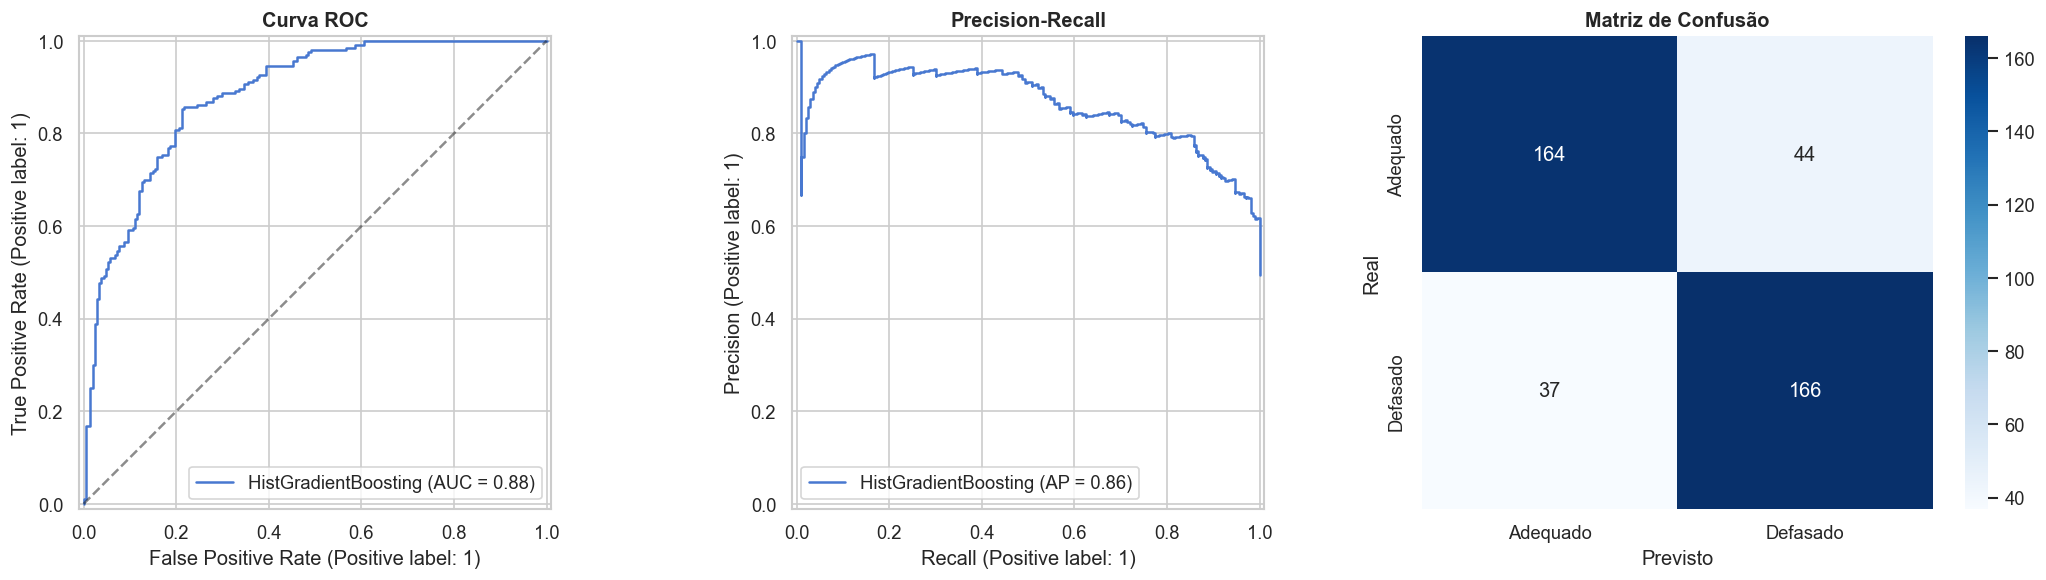

In [38]:
modelo = HistGradientBoostingClassifier(**HIPERPARAMETROS)
modelo.fit(X_treino, y_treino)
y_prob = modelo.predict_proba(X_teste)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f'=== RESULTADOS (com otimização) ===')
print(f'|_  Treino: {len(X_treino)} | Teste: {len(X_teste)}')
print(f'|_  AUC: {roc_auc_score(y_teste, y_prob):.4f}')
print(classification_report(y_teste, y_pred, target_names=['Adequado', 'Defasado']))

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_teste, y_prob, ax=axes[0], name='HistGradientBoosting')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('Curva ROC', fontweight='bold')

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y_teste, y_prob, ax=axes[1], name='HistGradientBoosting')
axes[1].set_title('Precision-Recall', fontweight='bold')

# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Adequado', 'Defasado'], yticklabels=['Adequado', 'Defasado'])
axes[2].set_title('Matriz de Confusão', fontweight='bold')
axes[2].set_xlabel('Previsto')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()

### Feature Importance

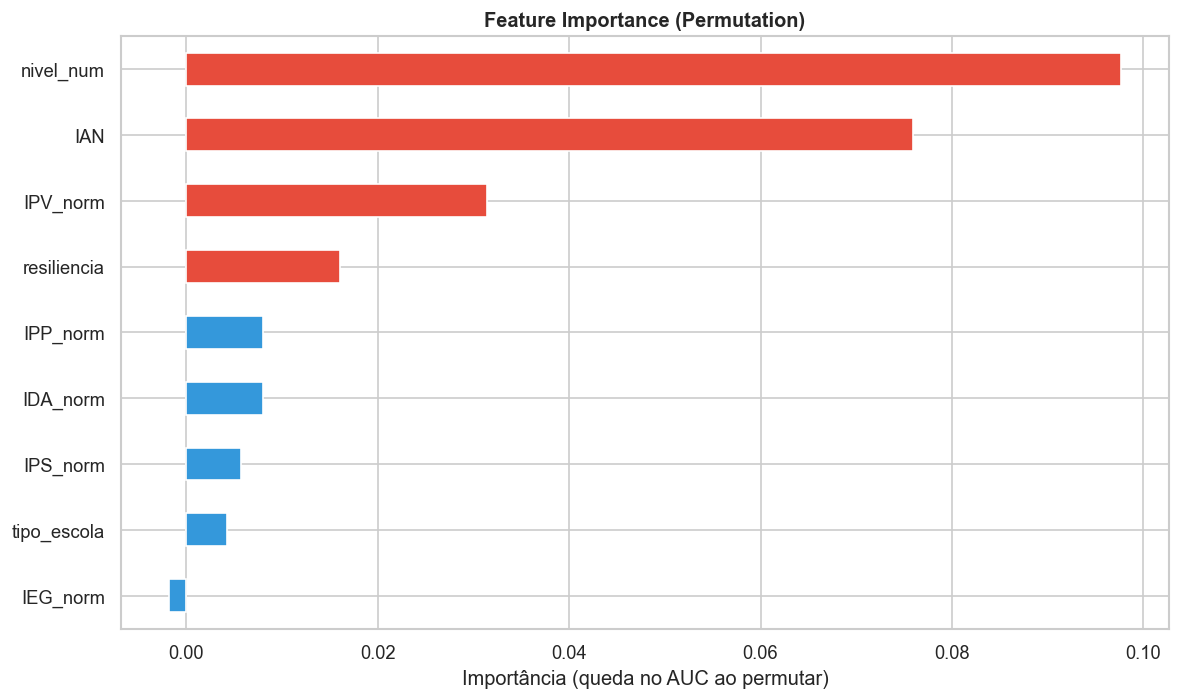

=== Ranking de features ===
|_  nivel_num           : 0.0977
|_  IAN                 : 0.0759
|_  IPV_norm            : 0.0314
|_  resiliencia         : 0.0161
|_  IPP_norm            : 0.0080
|_  IDA_norm            : 0.0080
|_  IPS_norm            : 0.0057
|_  tipo_escola         : 0.0042
|_  IEG_norm            : -0.0019


In [40]:
# Feature importance via permutation
result = permutation_importance(modelo, X_teste, y_teste, 
                                 n_repeats=10, random_state=42, scoring='roc_auc')

feat_imp = pd.Series(result.importances_mean, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', ax=ax, 
              color=['#e74c3c' if v > feat_imp.median() else '#3498db' for v in feat_imp.values])
ax.set_title('Feature Importance (Permutation)', fontweight='bold')
ax.set_xlabel('Importância (queda no AUC ao permutar)')
plt.tight_layout()
plt.show()

print('=== Ranking de features ===')
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f'|_  {feat:20}: {imp:.4f}')

In [ ]:
# Modelo final: treinar com todos os dados
modelo_final = HistGradientBoostingClassifier(
    max_iter=200, max_depth=6, learning_rate=0.1, random_state=42
)
modelo_final.fit(X_all, y_all)

print('✅ Modelo final treinado com todo o dataset (1369 amostras)')
print(f'   AUC (CV 5-fold): 0.8494 ± 0.0132')
print(f'   Acurácia (CV 5-fold): 0.7721 ± 0.0255')

✅ Modelo final treinado com todo o dataset (1369 amostras)
   AUC (CV 5-fold): 0.8494 ± 0.0132
   Acurácia (CV 5-fold): 0.7721 ± 0.0255


### Análise de probabilidades

=== Faixas de risco ===
               n  pct_defasado
faixa_risco                   
Muito baixo  103           3.9
Baixo         65          29.2
Moderado      73          52.1
Alto          78          71.8
Muito alto    92          93.5


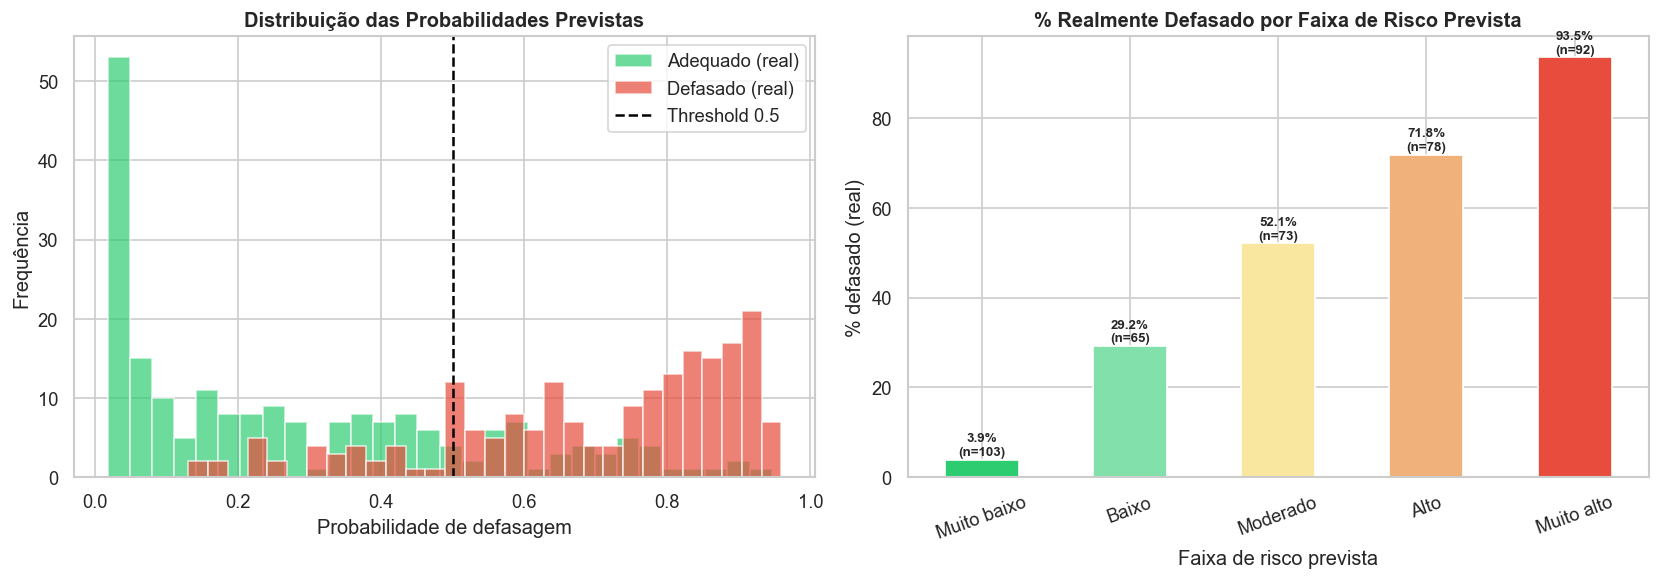

In [ ]:
# Análise das probabilidades previstas pelo modelo
# Objetivo: avaliar a qualidade das probabilidades e criar faixas de risco práticas para a ONG

# Recuperar dados dos alunos de teste com suas probabilidades previstas
df_teste_result = df_pares.loc[X_teste.index, ['RA', 'ano_atual', 'target']].copy()
df_teste_result['prob_defasagem'] = y_prob

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribuição das probabilidades
# Mostra se o modelo separa bem os dois grupos:
#   - Adequados (verde) devem concentrar à esquerda (prob baixa)
#   - Defasados (vermelho) devem concentrar à direita (prob alta)
#   - Quanto menos sobreposição, melhor o modelo
axes[0].hist(df_teste_result[df_teste_result['target'] == 0]['prob_defasagem'],
             bins=30, alpha=0.7, label='Adequado (real)', color='#2ecc71')
axes[0].hist(df_teste_result[df_teste_result['target'] == 1]['prob_defasagem'],
             bins=30, alpha=0.7, label='Defasado (real)', color='#e74c3c')
axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[0].set_title('Distribuição das Probabilidades Previstas', fontweight='bold')
axes[0].set_xlabel('Probabilidade de defasagem')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Faixas de risco
# Agrupa alunos em 5 faixas baseadas na probabilidade prevista
# Cada faixa cobre 20% da escala de probabilidade (0-20%, 20-40%, etc.)
# Podemos usar essas faixas para identificar probabilidades de defasagem em categorias:
#   - "Muito baixo": alunos que provavelmente ficarão adequados
#   - "Muito alto": alunos que quase certamente ficarão defasados — prioridade de intervenção
df_teste_result['faixa_risco'] = pd.cut(df_teste_result['prob_defasagem'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Muito baixo', 'Baixo', 'Moderado', 'Alto', 'Muito alto'])

# Calcular: em cada faixa, qual % realmente ficou defasado?
# Isso valida se as probabilidades do modelo refletem o risco real
faixa_stats = df_teste_result.groupby('faixa_risco').agg(
    n=('target', 'count'),
    pct_defasado=('target', 'mean')
).round(3)
faixa_stats['pct_defasado'] = (faixa_stats['pct_defasado'] * 100).round(1)

print('=== Faixas de risco ===')
print(faixa_stats.to_string())

# Gráfico 2: Validação das faixas de risco
# Se o modelo for bom, o % real de defasados deve subir junto com a faixa
# Gradiente ideal: Muito baixo ~0% → Muito alto ~100%
cores_faixa = ['#2ecc71', '#82e0aa', '#f9e79f', '#f0b27a', '#e74c3c']
faixa_stats['pct_defasado'].plot(kind='bar', ax=axes[1], color=cores_faixa)
axes[1].set_title('% Realmente Defasado por Faixa de Risco Prevista', fontweight='bold')
axes[1].set_ylabel('% defasado (real)')
axes[1].set_xlabel('Faixa de risco prevista')
axes[1].tick_params(axis='x', rotation=20)

for i, (faixa, row) in enumerate(faixa_stats.iterrows()):
    axes[1].text(i, row['pct_defasado'] + 1, f'{row["pct_defasado"]:.1f}%\n(n={int(row["n"])})',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()